 # Evaluating the Reliability of Deepfake Detection Models Against Modern AI-Generated Identity Images
**Beyza Saglam - MSc Computing, University of Roehampton**

---

## Experiment Pipeline
1. Mount Google Drive & verify datasets
2. Extract frames / copy images to Colab disk
3. Install dependencies & imports
4. Define Dataset classes and evaluate() helper
5. Train all 4 models (XceptionNet, EfficientNet-B4, ResNet50, DenseNet121)
6. Evaluate: within-dataset (FF++), cross-dataset (CelebDF-v2), cross-generation (GenImage)
7. Compression simulation (q = 90, 70, 50, 30)
8. Generate all plots and tables (Figures 3-12)
9. Save everything to Google Drive

---
### Dataset sizes
| Dataset | Real | Fake | Total | Purpose |
|---------|------|------|-------|---------|
| FF++ - train | 1000 frames | 1000 frames | 2000 | Training only (videos 000-159) |
| FF++ - test  | 1000 frames | 1000 frames | 2000 | Within-dataset test (videos 160-199) |
| CelebDF-v2   | 1000 frames | 1000 frames | 2000 | Cross-dataset test |
| GenImage (sdv4) | 1000 images | 1000 images | 2000 | Cross-generation test |

**FF++ train/test are separated at the VIDEO level - zero frame overlap.**
- Videos 000-159 (160 videos) -> training
- Videos 160-199 (40 videos)  -> within-dataset test only
- CelebDF and GenImage are test-only - no training, no frame extraction needed for GenImage (already images).

---
### Drive structure (`MyDrive/dataset/`)
```
dataset/
+-- faceforensics_download_v4.py
+-- ff_plus/
|   +-- manipulated_sequences/Deepfakes/c23/videos/   (200 .mp4 fake)
+-- ff_real/
|   +-- original_sequences/youtube/c23/videos/        (200 .mp4 real)
+-- celebdf/
|   +-- Celeb-real/      (590 videos)
|   +-- Celeb-synthesis/ (5639 videos)
|   +-- YouTube-real/    (300 videos)
+-- genimage/
|   +-- fake/  (6000 .png - Stable Diffusion v1.4)
|   +-- real/  (6000 .jpg - ImageNet)
+-- results/   (model weights + plots saved here)
```


---



---
## STEP 0 - Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/dataset'
print('Drive contents:')
for item in sorted(os.listdir(BASE)):
    full = os.path.join(BASE, item)
    if os.path.isdir(full):
        n = sum(len(f) for _, _, f in os.walk(full))
        print(f'  {item}/ - {n} files')
    else:
        gb = os.path.getsize(full) / 1024**3
        print(f'  {item} - {gb:.2f} GB')

Mounted at /content/drive
Drive contents:
  Celeb-DF-v2.zip - 9.27 GB
  celebdf/ - 6530 files
  download_script.py - 0.00 GB
  faceforensics_download_v4.py - 0.00 GB
  ff_plus/ - 201 files
  ff_real/ - 200 files
  frames/ - 1000 files
  genimage/ - 12000 files
  genimage_snapshot_download/ - 0 files
  genimage_zip/ - 3 files
  genimage_zip_extracted/ - 0 files
  results/ - 10 files
  stable_diffusion_v_1_4/ - 30 files


---
## STEP 1 - Verify Datasets on Drive

In [ ]:
import os

checks = {
    'FF++ fake videos (200)':   '/content/drive/MyDrive/dataset/ff_plus/manipulated_sequences/Deepfakes/c23/videos',
    'FF++ real videos (200)':   '/content/drive/MyDrive/dataset/ff_real/original_sequences/youtube/c23/videos',
    'CelebDF Celeb-real':       '/content/drive/MyDrive/dataset/celebdf/Celeb-real',
    'CelebDF Celeb-synthesis':  '/content/drive/MyDrive/dataset/celebdf/Celeb-synthesis',
    'GenImage fake (6000)':     '/content/drive/MyDrive/dataset/genimage/fake',
    'GenImage real (6000)':     '/content/drive/MyDrive/dataset/genimage/real',
}

all_ok = True
for name, path in checks.items():
    if os.path.exists(path):
        n = len(os.listdir(path))
        print(f'{name}: {n} items')
    else:
        print(f'{name}: NOT FOUND at {path}')
        all_ok = False

if all_ok:
    print('\nAll datasets found - ready to proceed!')
else:
    print('\nERROR: fix missing datasets before continuing.')


FF++ fake videos (200): 200 items
FF++ real videos (200): 200 items
CelebDF Celeb-real: 590 items
CelebDF Celeb-synthesis: 5639 items
GenImage fake (6000): 6000 items
GenImage real (6000): 6000 items

All datasets found - ready to proceed!


---
## STEP 2 - Extract Data to Colab Disk

### What gets extracted and why:
| Data | Method | Reason |
|------|--------|--------|
| FF++ real/fake (train) | Extract frames from videos | Video dataset |
| FF++ real/fake (test)  | Extract frames from videos | Video dataset, different videos |
| CelebDF real/fake      | Extract frames from videos | Video dataset |
| GenImage real/fake     | Copy images directly       | Already images, no extraction needed |

### FF++ video-level split:
- Sorted alphabetically -> first 160 videos = train, last 40 videos = test
- 160 train videos x 7 frames  = ~1000 frames per class
- 40 test videos  x 25 frames  = ~1000 frames per class

### Target counts:
```
frames/
+-- train_real/      1000 frames  <- FF++ real  (videos 000-159)
+-- train_fake/      1000 frames  <- FF++ fake  (videos 000-159)
+-- test_ff_real/    1000 frames  <- FF++ real  (videos 160-199)
+-- test_ff_fake/    1000 frames  <- FF++ fake  (videos 160-199)
+-- test_celeb_real/ 1000 frames  <- CelebDF Celeb-real + YouTube-real
+-- test_celeb_fake/ 1000 frames  <- CelebDF Celeb-synthesis
+-- test_gen_real/   1000 images  <- GenImage real (ImageNet)
+-- test_gen_fake/   1000 images  <- GenImage fake (sdv4)
```


In [ ]:
import os

DIRS = [
    '/content/data/frames/train_real',
    '/content/data/frames/train_fake',
    '/content/data/frames/test_ff_real',
    '/content/data/frames/test_ff_fake',
    '/content/data/frames/test_celeb_real',
    '/content/data/frames/test_celeb_fake',
    '/content/data/frames/test_gen_real',
    '/content/data/frames/test_gen_fake',
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)

stat = os.statvfs('/content')
free_gb = stat.f_bavail * stat.f_frsize / 1024**3
print(f'Free disk space: {free_gb:.1f} GB')
print('Directories created' if free_gb >= 10 else 'WARNING: low disk space - need ~10 GB free!')


Free disk space: 192.7 GB
Directories created


In [ ]:
# CelebDF-v2 is already extracted on Google Drive at dataset/celebdf/
# No unzip needed - we read directly from Drive during frame extraction.
import os

celeb_real_path = '/content/drive/MyDrive/dataset/celebdf/Celeb-real'
celeb_synth_path = '/content/drive/MyDrive/dataset/celebdf/Celeb-synthesis'
youtube_real_path = '/content/drive/MyDrive/dataset/celebdf/YouTube-real'

print(f'CelebDF Celeb-real:      {len(os.listdir(celeb_real_path))} videos')
print(f'CelebDF Celeb-synthesis: {len(os.listdir(celeb_synth_path))} videos')
print(f'CelebDF YouTube-real:    {len(os.listdir(youtube_real_path))} videos')
print('\nCelebDF ready - reading from Drive directly')


CelebDF Celeb-real:      590 videos
CelebDF Celeb-synthesis: 5639 videos
CelebDF YouTube-real:    300 videos

CelebDF ready - reading from Drive directly


In [ ]:
import cv2, os, random, shutil
from pathlib import Path

def extract_frames_video_split(video_dir, train_out, test_out,
                               train_label, test_label,
                               train_videos=160, test_videos=40,
                               train_target=1000, test_target=1000,
                               frames_per_video_train=7,
                               frames_per_video_test=25):
    """
    Split videos into train/test at the VIDEO level (no frame overlap).
    Videos are sorted alphabetically then split:
      - First train_videos  -> training frames
      - Next  test_videos   -> test frames
    """
    videos = sorted(Path(video_dir).rglob('*.mp4'))
    if not videos:
        print(f'No .mp4 files found in {video_dir}')
        return 0, 0

    train_vids = videos[:train_videos]
    test_vids  = videos[train_videos:train_videos + test_videos]
    print(f'  Videos available: {len(videos)} | train: {len(train_vids)} | test: {len(test_vids)}')

    def extract(vid_list, out_dir, label, target, fpv):
        existing = len([f for f in os.listdir(out_dir) if f.endswith('.jpg')])
        if existing >= target:
            print(f'  {label}: already has {existing} frames - skipping')
            return existing
        for f in os.listdir(out_dir):
            os.remove(os.path.join(out_dir, f))
        count = 0
        for video in vid_list:
            if count >= target:
                break
            cap = cv2.VideoCapture(str(video))
            total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total_f < fpv:
                cap.release()
                continue
            indices = [int(total_f * (0.1 + 0.8 * i / max(fpv - 1, 1)))
                       for i in range(fpv)]
            for idx in indices:
                if count >= target:
                    break
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if ret:
                    cv2.imwrite(f'{out_dir}/{label}_{count:05d}.jpg', frame)
                    count += 1
            cap.release()
        print(f'  {label}: {count} frames')
        return count

    n_train = extract(train_vids, train_out, train_label,
                      train_target, frames_per_video_train)
    n_test  = extract(test_vids,  test_out,  test_label,
                      test_target, frames_per_video_test)
    return n_train, n_test


def extract_frames_from_videos(video_dirs, output_dir, label, target=1000, frames_per_video=5):
    """Extract frames from one or more video dirs into a single output dir."""
    if isinstance(video_dirs, str):
        video_dirs = [video_dirs]
    existing = len([f for f in os.listdir(output_dir) if f.endswith('.jpg')])
    if existing >= target:
        print(f'  {label}: already has {existing} frames - skipping')
        return existing
    for f in os.listdir(output_dir):
        os.remove(os.path.join(output_dir, f))
    all_videos = []
    for vdir in video_dirs:
        all_videos.extend(sorted(Path(vdir).rglob('*.mp4')))
    random.shuffle(all_videos)
    if not all_videos:
        print(f'  No .mp4 found in {video_dirs}')
        return 0
    count = 0
    n_needed = -(-target // frames_per_video)
    for video in all_videos[:n_needed]:
        if count >= target: break
        cap = cv2.VideoCapture(str(video))
        total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_f < frames_per_video:
            cap.release(); continue
        indices = [int(total_f * (0.1 + 0.8 * i / max(frames_per_video - 1, 1)))
                   for i in range(frames_per_video)]
        for idx in indices:
            if count >= target: break
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                cv2.imwrite(f'{output_dir}/{label}_{count:05d}.jpg', frame)
                count += 1
        cap.release()
    print(f'  {label}: {count} frames')
    return count


def copy_images_subset(src_dir, output_dir, label, n=1000):
    """Copy a random subset of images. Skips if already done."""
    existing = len([f for f in os.listdir(output_dir) if f.endswith('.jpg')])
    if existing >= n:
        print(f'  {label}: already has {existing} images - skipping')
        return existing
    for f in os.listdir(output_dir):
        os.remove(os.path.join(output_dir, f))
    files = [f for f in os.listdir(src_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(files)
    for i, f in enumerate(files[:n]):
        shutil.copy(os.path.join(src_dir, f), f'{output_dir}/{label}_{i:05d}.jpg')
    print(f'  {label}: {min(len(files), n)} images copied')
    return min(len(files), n)


# ===============================================================================
print('=== [1-2] FF++ Video-Level Train/Test Split ===')
print('  Real videos - first 160 -> train | last 40 -> test')
extract_frames_video_split(
    video_dir  = '/content/drive/MyDrive/dataset/ff_real/original_sequences/youtube/c23/videos',
    train_out  = '/content/data/frames/train_real',
    test_out   = '/content/data/frames/test_ff_real',
    train_label= 'ff_real_train',
    test_label = 'ff_real_test',
    train_videos=160, test_videos=40,
    train_target=1000, test_target=1000,
    frames_per_video_train=7,
    frames_per_video_test=25)

print()
print('  Fake videos - first 160 -> train | last 40 -> test')
extract_frames_video_split(
    video_dir  = '/content/drive/MyDrive/dataset/ff_plus/manipulated_sequences/Deepfakes/c23/videos',
    train_out  = '/content/data/frames/train_fake',
    test_out   = '/content/data/frames/test_ff_fake',
    train_label= 'ff_fake_train',
    test_label = 'ff_fake_test',
    train_videos=160, test_videos=40,
    train_target=1000, test_target=1000,
    frames_per_video_train=7,
    frames_per_video_test=25)

print()
print('=== [3] CelebDF real -> test_celeb_real (1000 frames) ===')
extract_frames_from_videos(
    ['/content/drive/MyDrive/dataset/celebdf/Celeb-real',
     '/content/drive/MyDrive/dataset/celebdf/YouTube-real'],
    '/content/data/frames/test_celeb_real', 'celeb_real', target=1000, frames_per_video=3)

print()
print('=== [4] CelebDF fake -> test_celeb_fake (1000 frames) ===')
extract_frames_from_videos(
    '/content/drive/MyDrive/dataset/celebdf/Celeb-synthesis',
    '/content/data/frames/test_celeb_fake', 'celeb_fake', target=1000, frames_per_video=3)

print()
print('=== [5] GenImage real -> test_gen_real (1000 images) ===')
copy_images_subset(
    '/content/drive/MyDrive/dataset/genimage/real',
    '/content/data/frames/test_gen_real', 'gen_real', n=1000)

print()
print('=== [6] GenImage fake -> test_gen_fake (1000 images) ===')
copy_images_subset(
    '/content/drive/MyDrive/dataset/genimage/fake',
    '/content/data/frames/test_gen_fake', 'gen_fake', n=1000)

print('\n=== Final Summary ===')
targets = {
    'train_real':      1000,
    'train_fake':      1000,
    'test_ff_real':    1000,
    'test_ff_fake':    1000,
    'test_celeb_real': 1000,
    'test_celeb_fake': 1000,
    'test_gen_real':   1000,
    'test_gen_fake':   1000,
}
all_ok = True
for d, t in targets.items():
    n = len(os.listdir(f'/content/data/frames/{d}'))
    ok = n >= t
    if not ok: all_ok = False
    print(f'  [{"OK" if ok else "!!"}] {d}: {n}/{t}')
if all_ok:
    print('\nAll targets met!')
else:
    print('\nWARNING: some targets not met - check video counts above.')


=== [1-2] FF++ Video-Level Train/Test Split ===
  Real videos - first 160 -> train | last 40 -> test
  Videos available: 200 | train: 160 | test: 40
  ff_real_train: already has 1000 frames - skipping
  ff_real_test: already has 1000 frames - skipping

  Fake videos - first 160 -> train | last 40 -> test
  Videos available: 200 | train: 160 | test: 40
  ff_fake_train: already has 1000 frames - skipping
  ff_fake_test: already has 1000 frames - skipping

=== [3] CelebDF real -> test_celeb_real (1000 frames) ===
  celeb_real: already has 1000 frames - skipping

=== [4] CelebDF fake -> test_celeb_fake (1000 frames) ===
  celeb_fake: 1000 frames

=== [5] GenImage real -> test_gen_real (1000 images) ===
  gen_real: already has 1000 images - skipping

=== [6] GenImage fake -> test_gen_fake (1000 images) ===
  gen_fake: already has 1000 images - skipping

=== Final Summary ===
  train_real: 1000/1000
  train_fake: 1000/1000
  test_ff_real: 1000/1000
  test_ff_fake: 1000/1000
  test_celeb_real

---
## STEP 3 - Install Dependencies & Imports

In [ ]:
!pip install timm scikit-learn -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import cv2
import numpy as np
import os, random, io, shutil
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device:  {device}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')
print(f'PyTorch: {torch.__version__}')
print(f'timm:    {timm.__version__}')
print('All imports OK!')

Device:  cuda
GPU:     Tesla T4
PyTorch: 2.10.0+cu128
timm:    1.0.26
All imports OK!


---
## STEP 4 - Dataset Classes & Evaluation Helper

In [ ]:
# -- Transforms ----------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# -- DeepfakeDataset -----------------------------------------------------------
class DeepfakeDataset(Dataset):
    """
    Loads images from two flat directories (real_dir and fake_dir).
    Label 0 = real, 1 = fake.
    max_per_class caps the number of images per class.
    """
    def __init__(self, real_dir, fake_dir, transform=None, max_per_class=500):
        self.transform = transform
        self.samples = []

        real_imgs = sorted([f for f in os.listdir(real_dir)
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        fake_imgs = sorted([f for f in os.listdir(fake_dir)
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

        random.shuffle(real_imgs)
        random.shuffle(fake_imgs)

        for f in real_imgs[:max_per_class]:
            self.samples.append((os.path.join(real_dir, f), 0))
        for f in fake_imgs[:max_per_class]:
            self.samples.append((os.path.join(fake_dir, f), 1))

        random.shuffle(self.samples)
        print(f'  Dataset loaded: {len(self.samples)} images '
              f'({len(real_imgs[:max_per_class])} real, '
              f'{len(fake_imgs[:max_per_class])} fake)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, label
        except Exception:
            # Return a black image on corrupt file
            return torch.zeros(3, 224, 224), label


# -- CompressedDataset ---------------------------------------------------------
class CompressedDataset(Dataset):
    """
    Wraps an existing DeepfakeDataset and applies JPEG compression
    at the given quality level (1-95) on-the-fly.
    """
    def __init__(self, base_dataset, quality):
        self.base = base_dataset
        self.quality = quality
        # We need to re-read originals without normalisation first
        self.paths_labels = base_dataset.samples
        self.transform = base_dataset.transform  # reuse test_transform

    def __len__(self):
        return len(self.paths_labels)

    def __getitem__(self, idx):
        path, label = self.paths_labels[idx]
        try:
            img = Image.open(path).convert('RGB')
            # Encode to JPEG in memory at specified quality
            buffer = io.BytesIO()
            img.save(buffer, format='JPEG', quality=self.quality)
            buffer.seek(0)
            img = Image.open(buffer).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, label
        except Exception:
            return torch.zeros(3, 224, 224), label




# -- Evaluate function ---------------------------------------------------------
def evaluate(model, loader):
    """
    Returns dict with acc, auc, prec, rec, f1, cm, fpr, tpr.
    """
    model.eval()
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    cm   = confusion_matrix(all_labels, all_preds)
    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    return {'acc': acc, 'auc': auc, 'prec': prec, 'rec': rec,
            'f1': f1, 'cm': cm, 'fpr': fpr, 'tpr': tpr,
            'probs': all_probs, 'labels': all_labels}


print('Dataset classes and evaluate() defined.')


Dataset classes and evaluate() defined.


---
## STEP 5 - Load Training & Test Datasets

In [ ]:
import os, random
random.seed(42)

print('Loading datasets...')
print()

# -- FF++ Training dataset: 1000 real + 1000 fake (videos 000-159) -------------
print('Train FF++ (1000 real + 1000 fake = 2000 - videos 000-159 only):')
train_dataset = DeepfakeDataset(
    '/content/data/frames/train_real',
    '/content/data/frames/train_fake',
    train_transform, max_per_class=1000)

# -- FF++ Within-dataset test: 1000 real + 1000 fake (videos 160-199 only) -----
# These videos were NEVER seen during training - clean baseline evaluation
print('Test FF++ (1000 real + 1000 fake = 2000 - held-out videos 160-199):')
test_ff_dataset = DeepfakeDataset(
    '/content/data/frames/test_ff_real',
    '/content/data/frames/test_ff_fake',
    test_transform, max_per_class=1000)

# -- CelebDF-v2 Cross-dataset test: 1000 real + 1000 fake ---------------------
print('Test CelebDF-v2 (1000 real + 1000 fake = 2000):')
test_celeb_dataset = DeepfakeDataset(
    '/content/data/frames/test_celeb_real',
    '/content/data/frames/test_celeb_fake',
    test_transform, max_per_class=1000)

# -- GenImage Cross-generation test: 1000 real + 1000 fake -------------------
print('Test GenImage (1000 real + 1000 fake = 2000):')
test_gen_dataset = DeepfakeDataset(
    '/content/data/frames/test_gen_real',
    '/content/data/frames/test_gen_fake',
    test_transform, max_per_class=1000)

# -- DataLoaders ---------------------------------------------------------------
train_loader = DataLoader(train_dataset,      batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
ff_loader    = DataLoader(test_ff_dataset,    batch_size=32, shuffle=False, num_workers=2)
celeb_loader = DataLoader(test_celeb_dataset, batch_size=32, shuffle=False, num_workers=2)
gen_loader   = DataLoader(test_gen_dataset,   batch_size=32, shuffle=False, num_workers=2)

print()
print(f'  train_loader:  {len(train_dataset):4d} images  (FF++ train)')
print(f'  ff_loader:     {len(test_ff_dataset):4d} images  (FF++ test - unseen videos)')
print(f'  celeb_loader:  {len(test_celeb_dataset):4d} images  (CelebDF-v2)')
print(f'  gen_loader:    {len(test_gen_dataset):4d} images  (GenImage - 1000 real + 1000 fake)')
print('\nAll DataLoaders ready!')


Loading datasets...

Train FF++ (1000 real + 1000 fake = 2000 - videos 000-159 only):
  Dataset loaded: 2000 images (1000 real, 1000 fake)
Test FF++ (1000 real + 1000 fake = 2000 - held-out videos 160-199):
  Dataset loaded: 2000 images (1000 real, 1000 fake)
Test CelebDF-v2 (1000 real + 1000 fake = 2000):
  Dataset loaded: 2000 images (1000 real, 1000 fake)
Test GenImage (1000 real + 1000 fake = 2000):
  Dataset loaded: 2000 images (1000 real, 1000 fake)

  train_loader:  2000 images  (FF++ train)
  ff_loader:     2000 images  (FF++ test - unseen videos)
  celeb_loader:  2000 images  (CelebDF-v2)
  gen_loader:    2000 images  (GenImage - 1000 real + 1000 fake)

All DataLoaders ready!


---
## STEP 6 - Training Function

In [ ]:
def train_model(model_name, timm_name, epochs=10, lr=1e-4):
    """
    Train a single model on FF++ data.
    Returns (model, history_dict).
    """
    print(f'\n{"="*55}')
    print(f'  Training {model_name} for {epochs} epochs')
    print(f'{"="*55}')

    model = timm.create_model(timm_name, pretrained=True, num_classes=2)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

    history = {'loss': [], 'acc': []}
    best_acc = 0.0
    save_path = f'/content/{model_name.lower().replace("-","_")}_best.pth'

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        epoch_loss = total_loss / len(train_loader)
        epoch_acc  = correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        star = '*' if epoch_acc > best_acc else ''
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            torch.save(model.state_dict(), save_path)

        print(f'  Epoch {epoch+1:2d}/{epochs} - '
              f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} {star}')

    # Load best weights
    model.load_state_dict(torch.load(save_path, map_location=device))
    print(f'\n  Best accuracy: {best_acc:.4f} - weights loaded')
    return model, history


print('train_model() defined.')


train_model() defined.


---
## STEP 7 - Train All 4 Models
Estimated time on T4 GPU: ~15-20 min total

In [ ]:
# XceptionNet
xception_model, xception_history = train_model('XceptionNet', 'xception', epochs=10, lr=1e-4)


  Training XceptionNet for 10 epochs


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
  Epoch  1/10 - Loss: 0.6954 | Acc: 0.4920 
  Epoch  2/10 - Loss: 0.6932 | Acc: 0.5005 
  Epoch  3/10 - Loss: 0.6931 | Acc: 0.5010 
  Epoch  4/10 - Loss: 0.6931 | Acc: 0.5040 
  Epoch  5/10 - Loss: 0.6929 | Acc: 0.5245 
  Epoch  6/10 - Loss: 0.6647 | Acc: 0.5865 
  Epoch  7/10 - Loss: 0.4382 | Acc: 0.7765 
  Epoch  8/10 - Loss: 0.2568 | Acc: 0.8835 
  Epoch  9/10 - Loss: 0.1592 | Acc: 0.9265 
  Epoch 10/10 - Loss: 0.1032 | Acc: 0.9585 

  Best accuracy: 0.9585 - weights loaded


In [ ]:
# EfficientNet-B4
efficientnet_model, efficientnet_history = train_model('EfficientNet-B4', 'efficientnet_b4', epochs=10, lr=1e-4)


  Training EfficientNet-B4 for 10 epochs


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

  Epoch  1/10 - Loss: 1.1727 | Acc: 0.4745 
  Epoch  2/10 - Loss: 0.8314 | Acc: 0.5780 
  Epoch  3/10 - Loss: 0.7068 | Acc: 0.6375 
  Epoch  4/10 - Loss: 0.5871 | Acc: 0.7025 
  Epoch  5/10 - Loss: 0.5022 | Acc: 0.7445 
  Epoch  6/10 - Loss: 0.4204 | Acc: 0.8030 
  Epoch  7/10 - Loss: 0.3902 | Acc: 0.8255 
  Epoch  8/10 - Loss: 0.3534 | Acc: 0.8450 
  Epoch  9/10 - Loss: 0.3172 | Acc: 0.8675 
  Epoch 10/10 - Loss: 0.2994 | Acc: 0.8715 

  Best accuracy: 0.8715 - weights loaded


In [ ]:
# ResNet50
resnet_model, resnet_history = train_model('ResNet50', 'resnet50', epochs=10, lr=1e-4)


  Training ResNet50 for 10 epochs


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  Epoch  1/10 - Loss: 0.6963 | Acc: 0.4775 
  Epoch  2/10 - Loss: 0.6881 | Acc: 0.5460 
  Epoch  3/10 - Loss: 0.6596 | Acc: 0.6370 
  Epoch  4/10 - Loss: 0.5205 | Acc: 0.7665 
  Epoch  5/10 - Loss: 0.3597 | Acc: 0.8415 
  Epoch  6/10 - Loss: 0.2641 | Acc: 0.9005 
  Epoch  7/10 - Loss: 0.2393 | Acc: 0.8865 
  Epoch  8/10 - Loss: 0.2009 | Acc: 0.9185 
  Epoch  9/10 - Loss: 0.1641 | Acc: 0.9335 
  Epoch 10/10 - Loss: 0.1381 | Acc: 0.9440 

  Best accuracy: 0.9440 - weights loaded


In [ ]:
# DenseNet121
densenet_model, densenet_history = train_model('DenseNet121', 'densenet121', epochs=10, lr=1e-4)


  Training DenseNet121 for 10 epochs


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

  Epoch  1/10 - Loss: 0.6943 | Acc: 0.5435 
  Epoch  2/10 - Loss: 0.4156 | Acc: 0.7890 
  Epoch  3/10 - Loss: 0.2554 | Acc: 0.8915 
  Epoch  4/10 - Loss: 0.1674 | Acc: 0.9275 
  Epoch  5/10 - Loss: 0.0975 | Acc: 0.9675 
  Epoch  6/10 - Loss: 0.0772 | Acc: 0.9715 
  Epoch  7/10 - Loss: 0.0593 | Acc: 0.9835 
  Epoch  8/10 - Loss: 0.0654 | Acc: 0.9790 
  Epoch  9/10 - Loss: 0.0412 | Acc: 0.9925 
  Epoch 10/10 - Loss: 0.0385 | Acc: 0.9925 

  Best accuracy: 0.9925 - weights loaded


---
## STEP 8 - Evaluate All Models on All 3 Conditions

Three evaluation conditions:
1. Within-dataset  (FF++)    - model tested on same distribution it was trained on
2. Cross-dataset   (CelebDF) - GAN-based but different source, tests generalisation
3. Cross-generation(GenImage)- Stable Diffusion images, tests GAN->diffusion gap

Metrics reported:
- Accuracy: overall correct classifications
- AUC-ROC: area under ROC curve, threshold-independent performance measure
- Precision: of all images predicted fake, how many were actually fake
- Recall: of all actual fake images, how many were correctly detected
- F1: harmonic mean of precision and recall
- Acc Drop: accuracy difference vs FF++ baseline (negative = worse than baseline)


In [ ]:
MODELS = {
    'XceptionNet':     xception_model,
    'EfficientNet-B4': efficientnet_model,
    'ResNet50':        resnet_model,
    'DenseNet121':     densenet_model,
}

LOADERS = {
    'FF++':     ff_loader,
    'CelebDF':  celeb_loader,
    'GenImage': gen_loader,
}

# results[model_name][dataset_name] = metrics dict
results = {m: {} for m in MODELS}

for model_name, model in MODELS.items():
    print(f'\n--- {model_name} ---')
    for ds_name, loader in LOADERS.items():
        r = evaluate(model, loader)
        results[model_name][ds_name] = r
        print(f'  {ds_name:<10}  Acc={r["acc"]:.3f} | AUC={r["auc"]:.3f} | Prec={r["prec"]:.3f} | Rec={r["rec"]:.3f} | F1={r["f1"]:.3f}')

print('\n--- Accuracy Drop vs FF++ baseline ---')
for model_name in MODELS:
    ff_acc = results[model_name]['FF++']['acc']
    for ds_name in ['CelebDF', 'GenImage']:
        drop = results[model_name][ds_name]['acc'] - ff_acc
        print(f'  {model_name:<20} {ds_name:<10}  Drop={drop:+.3f} ({drop:.1%})')

print('\nAll evaluations complete!')


--- XceptionNet ---
  FF++        Acc=0.652 | AUC=0.715 | Prec=0.709 | Rec=0.517 | F1=0.598
  CelebDF     Acc=0.593 | AUC=0.626 | Prec=0.592 | Rec=0.596 | F1=0.594
  GenImage    Acc=0.493 | AUC=0.390 | Prec=0.496 | Rec=0.966 | F1=0.656

--- EfficientNet-B4 ---
  FF++        Acc=0.557 | AUC=0.578 | Prec=0.568 | Rec=0.476 | F1=0.518
  CelebDF     Acc=0.499 | AUC=0.519 | Prec=0.499 | Rec=0.446 | F1=0.471
  GenImage    Acc=0.493 | AUC=0.464 | Prec=0.495 | Rec=0.715 | F1=0.585

--- ResNet50 ---
  FF++        Acc=0.705 | AUC=0.763 | Prec=0.755 | Rec=0.606 | F1=0.672
  CelebDF     Acc=0.567 | AUC=0.612 | Prec=0.565 | Rec=0.575 | F1=0.570
  GenImage    Acc=0.487 | AUC=0.472 | Prec=0.493 | Rec=0.915 | F1=0.641

--- DenseNet121 ---
  FF++        Acc=0.748 | AUC=0.836 | Prec=0.851 | Rec=0.600 | F1=0.704
  CelebDF     Acc=0.553 | AUC=0.590 | Prec=0.561 | Rec=0.495 | F1=0.526
  GenImage    Acc=0.527 | AUC=0.554 | Prec=0.526 | Rec=0.548 | F1=0.537

--- Accuracy Drop vs FF++ baseline ---
  XceptionN

---
## STEP 9 - Compression Simulation (q = 90, 70, 50, 30)

In [ ]:
# -- STEP 9: JPEG Compression Simulation --------------------------------------
#
# Simulates real-world image transmission conditions (social media, messaging apps)
# which typically apply JPEG compression when images are uploaded or shared.
#
# Four compression quality levels tested:
#   q=90 - mild compression   (high quality, small artefacts)
#   q=70 - moderate compression
#   q=50 - heavy compression
#   q=30 - severe compression  (low quality, strong artefacts)
#
# Each model is tested against all 3 datasets at all 4 quality levels.
# Compression is applied in-memory using CompressedDataset (no files written to disk).
# Acc Drop = accuracy at compressed level minus original uncompressed accuracy.
# This answers RQ2: how does JPEG compression affect detection accuracy?
# -----------------------------------------------------------------------------

QUALITIES = [90, 70, 50, 30]

DATASETS_LIST = ['FF++', 'CelebDF', 'GenImage']
comp_results = {m: {ds: {} for ds in DATASETS_LIST} for m in MODELS}

TEST_DATASETS = {
    'FF++':     test_ff_dataset,
    'CelebDF':  test_celeb_dataset,
    'GenImage': test_gen_dataset,
}

for model_name, model in MODELS.items():
    print(f'\n--- {model_name} ---')
    for ds_name, base_ds in TEST_DATASETS.items():
        orig_acc = results[model_name][ds_name]['acc']
        print(f'  {ds_name} (original Acc={orig_acc:.3f}):')
        for q in QUALITIES:
            comp_ds = CompressedDataset(base_ds, quality=q)
            loader  = DataLoader(comp_ds, batch_size=32, shuffle=False, num_workers=0)
            r = evaluate(model, loader)
            comp_results[model_name][ds_name][q] = r
            drop = r['acc'] - orig_acc
            print(f'    q={q:3d} -> Acc={r["acc"]:.3f} | AUC={r["auc"]:.3f} | Prec={r["prec"]:.3f} | Rec={r["rec"]:.3f} | F1={r["f1"]:.3f} | Acc Drop={drop:+.3f}')

print('\nCompression simulation complete!')


--- XceptionNet ---
  FF++ (original Acc=0.652):
    q= 90 -> Acc=0.652 | AUC=0.714 | Prec=0.710 | Rec=0.516 | F1=0.598 | Acc Drop=+0.000
    q= 70 -> Acc=0.649 | AUC=0.714 | Prec=0.704 | Rec=0.516 | F1=0.595 | Acc Drop=-0.003
    q= 50 -> Acc=0.653 | AUC=0.712 | Prec=0.703 | Rec=0.530 | F1=0.604 | Acc Drop=+0.001
    q= 30 -> Acc=0.650 | AUC=0.713 | Prec=0.689 | Rec=0.548 | F1=0.611 | Acc Drop=-0.002
  CelebDF (original Acc=0.593):
    q= 90 -> Acc=0.596 | AUC=0.625 | Prec=0.595 | Rec=0.598 | F1=0.597 | Acc Drop=+0.003
    q= 70 -> Acc=0.599 | AUC=0.628 | Prec=0.595 | Rec=0.616 | F1=0.605 | Acc Drop=+0.006
    q= 50 -> Acc=0.597 | AUC=0.629 | Prec=0.591 | Rec=0.629 | F1=0.609 | Acc Drop=+0.004
    q= 30 -> Acc=0.595 | AUC=0.629 | Prec=0.583 | Rec=0.667 | F1=0.622 | Acc Drop=+0.002
  GenImage (original Acc=0.493):
    q= 90 -> Acc=0.494 | AUC=0.390 | Prec=0.497 | Rec=0.966 | F1=0.656 | Acc Drop=+0.001
    q= 70 -> Acc=0.493 | AUC=0.394 | Prec=0.497 | Rec=0.966 | F1=0.656 | Acc Drop=+0

---
## STEP 10 - Print Full Results Tables

In [ ]:
# -- STEP 10: Print Full Results Tables (matching thesis Tables 2-7) -----------
#
# Table 2: Training performance (best accuracy + final loss per model)
# Table 3: Within-dataset results - FF++ (2000 images)
# Table 4: Cross-dataset results - CelebDF-v2 (2000 images)
# Table 5: Cross-generation results - GenImage (2000 images)
# Table 6: Compression results - accuracy by model, dataset and quality level
# Table 7: Overall accuracy comparison across all conditions
#
# Note: Table 1 (literature review) is thesis-only, not generated here.
# -----------------------------------------------------------------------------

SEP  = '=' * 72
SEP2 = '-' * 72

# -- Table 2: Training Performance --------------------------------------------
print(SEP)
print('TABLE 2: Best Accuracy & Final Loss - Training Performance')
print(SEP)
print(f'  {"Model":<20} {"Best Acc":>10} {"Final Loss":>12}')
print(SEP2)
all_histories = {
    'XceptionNet':     xception_history,
    'EfficientNet-B4': efficientnet_history,
    'ResNet50':        resnet_history,
    'DenseNet121':     densenet_history,
}
for name, hist in all_histories.items():
    best_acc   = max(hist['acc'])
    final_loss = hist['loss'][-1]
    print(f'  {name:<20} {best_acc:>10.3f} {final_loss:>12.4f}')

# -- Tables 3-5: Evaluation Results -------------------------------------------
table_info = [
    ('FF++',     'TABLE 3: Within-Dataset Scores (FF++, 2000 images)',      None),
    ('CelebDF',  'TABLE 4: Cross-Dataset Results (CelebDF-v2, 2000 images)', 'FF++'),
    ('GenImage', 'TABLE 5: Cross-Generation Results (GenImage, 2000 images)','FF++'),
]

for ds, title, baseline_ds in table_info:
    print(f'\n{SEP}')
    print(title)
    print(SEP)
    if baseline_ds:
        print(f'  {"Model":<20} {"Acc":>6} {"AUC":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} {"Acc Drop":>10}')
    else:
        print(f'  {"Model":<20} {"Acc":>6} {"AUC":>6} {"Prec":>6} {"Rec":>6} {"F1":>6}')
    print(SEP2)
    for m in MODELS:
        r = results[m][ds]
        if baseline_ds:
            drop = r['acc'] - results[m][baseline_ds]['acc']
            print(f'  {m:<20} {r["acc"]:>6.3f} {r["auc"]:>6.3f} {r["prec"]:>6.3f} {r["rec"]:>6.3f} {r["f1"]:>6.3f} {drop:>+10.3f}')
        else:
            print(f'  {m:<20} {r["acc"]:>6.3f} {r["auc"]:>6.3f} {r["prec"]:>6.3f} {r["rec"]:>6.3f} {r["f1"]:>6.3f}')

print(f'\n{SEP}')
print('TABLE 6: Compression Results - Accuracy by Model, Dataset and Quality Level')
print(SEP)
print(f'  {"Model":<20} {"Dataset":<10} {"Original":>9} {"q=90":>6} {"q=70":>6} {"q=50":>6} {"q=30":>6}')
print(SEP2)
for m in MODELS:
    for ds in ['FF++', 'CelebDF', 'GenImage']:
        orig = results[m][ds]['acc']
        vals = [comp_results[m][ds][q]['acc'] for q in QUALITIES]
        print(f'  {m:<20} {ds:<10} {orig:>9.3f} {vals[0]:>6.3f} {vals[1]:>6.3f} {vals[2]:>6.3f} {vals[3]:>6.3f}')
    print()

# -- Table 7: Overall Accuracy Comparison -------------------------------------
print(SEP)
print('TABLE 7: Overall Accuracy Comparison Across All Conditions')
print(SEP)
print(f'  {"Model":<20} {"FF++":>8} {"CelebDF":>8} {"GenImage":>10} {"FF++ q=30":>10}')
print(SEP2)
for m in MODELS:
    ff_acc    = results[m]['FF++']['acc']
    celeb_acc = results[m]['CelebDF']['acc']
    gen_acc   = results[m]['GenImage']['acc']
    ff_q30    = comp_results[m]['FF++'][30]['acc']
    print(f'  {m:<20} {ff_acc:>8.3f} {celeb_acc:>8.3f} {gen_acc:>10.3f} {ff_q30:>10.3f}')



print(f'\n{SEP}')
print('All tables complete!')

TABLE 2: Best Accuracy & Final Loss - Training Performance
  Model                  Best Acc   Final Loss
------------------------------------------------------------------------
  XceptionNet               0.959       0.1032
  EfficientNet-B4           0.872       0.2994
  ResNet50                  0.944       0.1381
  DenseNet121               0.993       0.0385

TABLE 3: Within-Dataset Scores (FF++, 2000 images)
  Model                   Acc    AUC   Prec    Rec     F1
------------------------------------------------------------------------
  XceptionNet           0.652  0.715  0.709  0.517  0.598
  EfficientNet-B4       0.557  0.578  0.568  0.476  0.518
  ResNet50              0.705  0.763  0.755  0.606  0.672
  DenseNet121           0.748  0.836  0.851  0.600  0.704

TABLE 4: Cross-Dataset Results (CelebDF-v2, 2000 images)
  Model                   Acc    AUC   Prec    Rec     F1   Acc Drop
------------------------------------------------------------------------
  XceptionNet     

---
## STEP 11 - Generate All Plots

Plots saved to `/content/` and then copied to Drive.

In [ ]:
# -- STEP 11: Generate All Figures (3-12) -------------------------------------
#
# Figure 3:  Training loss and accuracy curves - all 4 models
# Figure 4:  Confusion matrices - Within-Dataset (FF++)
# Figure 5:  ROC curves - Within-Dataset (FF++)
# Figure 6:  Confusion matrices - Cross-Dataset (CelebDF-v2)
# Figure 7:  ROC curves - Cross-Dataset (CelebDF-v2)
# Figure 8:  Confusion matrices - Cross-Generation (GenImage)
# Figure 9:  ROC curves - Cross-Generation (GenImage)
# Figure 10: JPEG compression bar chart - all models, all datasets
# Figure 11: JPEG compression line chart - all models, all datasets
# Figure 12: Overall accuracy + AUC-ROC comparison bar chart
# Figure 13: Precision-Recall Curves - all models, all conditions
# Figure 14: Accuracy Heatmap - all models x all conditions
# Note: Figure 1 (Gantt chart) and Figure 2 (pipeline diagram)
# are thesis diagrams created manually in Word - not generated here.
# -----------------------------------------------------------------------------

# (matplotlib, seaborn, numpy, os already imported in STEP 3)
os.makedirs('/content/figures', exist_ok=True)

MODEL_NAMES = list(MODELS.keys())
COLORS      = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
DS_NAMES    = ['FF++', 'CelebDF', 'GenImage']
Q_LABELS    = ['Original', 'q=90', 'q=70', 'q=50', 'q=30']

print('Plot settings defined - run next cells for each figure.')

Plot settings defined - run next cells for each figure.


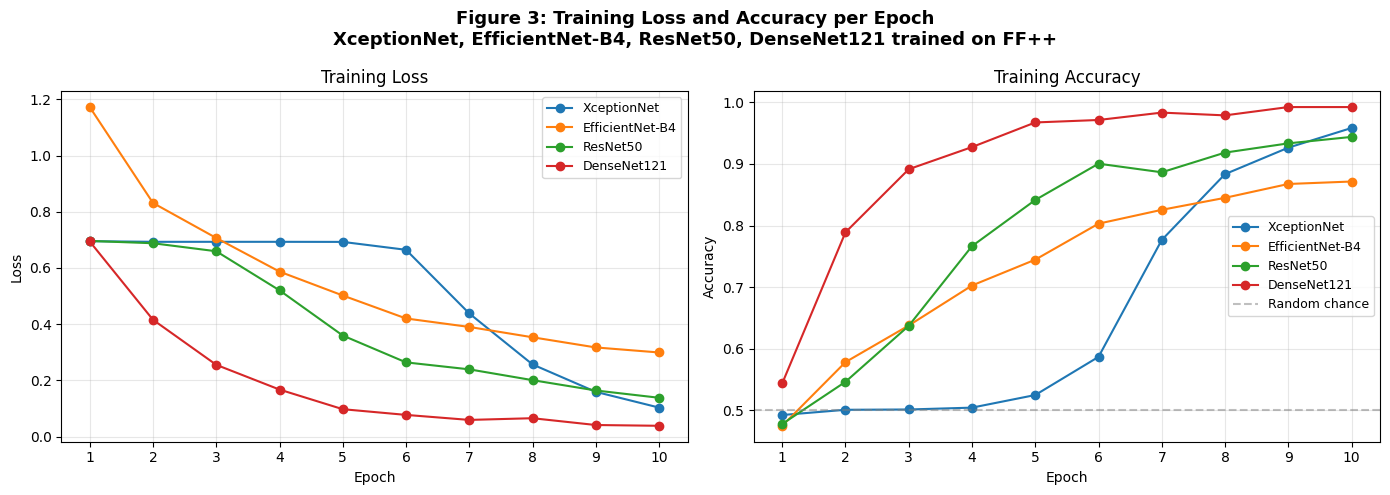

Figure 3 saved


In [ ]:
# -- Figure 3: Training Curves -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 3: Training Loss and Accuracy per Epoch\n'
             'XceptionNet, EfficientNet-B4, ResNet50, DenseNet121 trained on FF++',
             fontsize=13, fontweight='bold')

epochs_x = list(range(1, len(xception_history['loss']) + 1))

for i, (name, hist) in enumerate(all_histories.items()):
    axes[0].plot(epochs_x, hist['loss'], marker='o', label=name, color=COLORS[i])
    axes[1].plot(epochs_x, hist['acc'],  marker='o', label=name, color=COLORS[i])

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_x)

axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_x)

plt.tight_layout()
plt.savefig('/content/figures/figure3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')

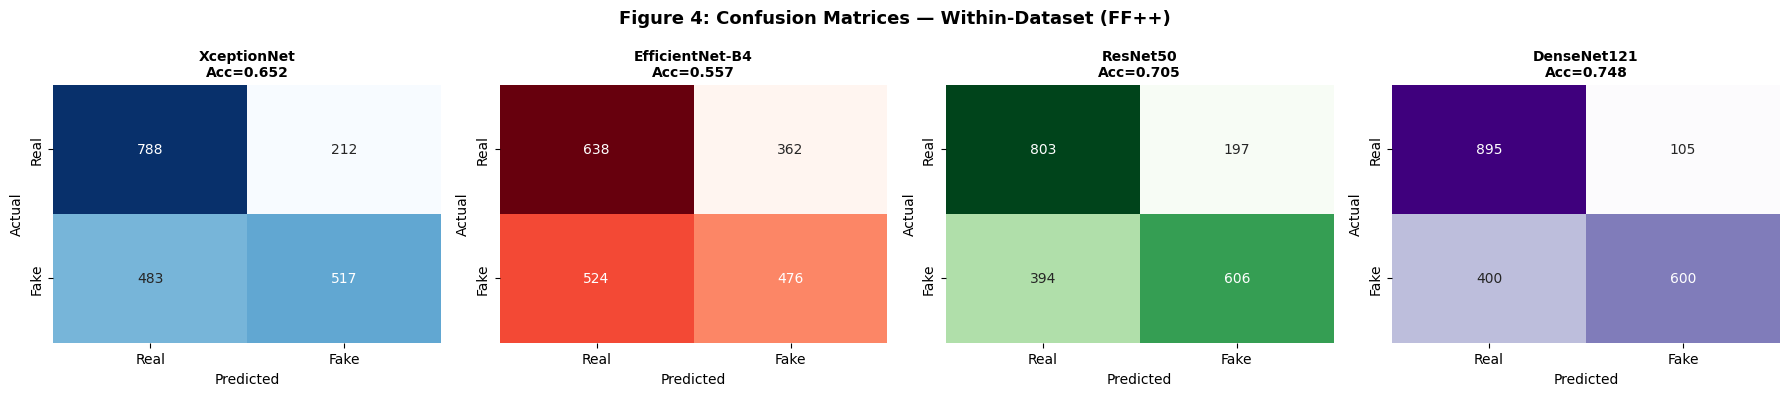

Figure 4 saved


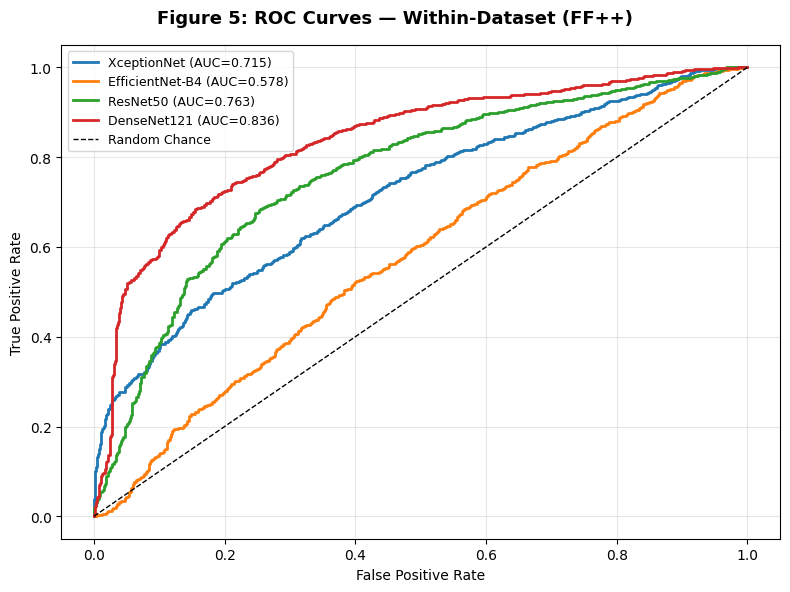

Figure 5 saved


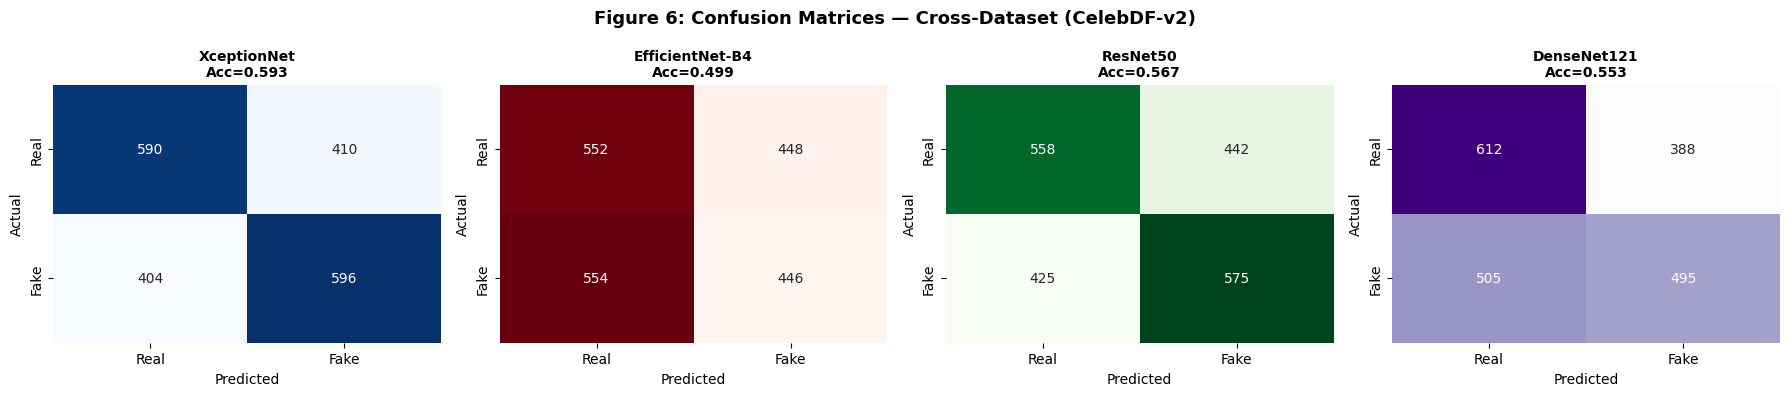

Figure 6 saved


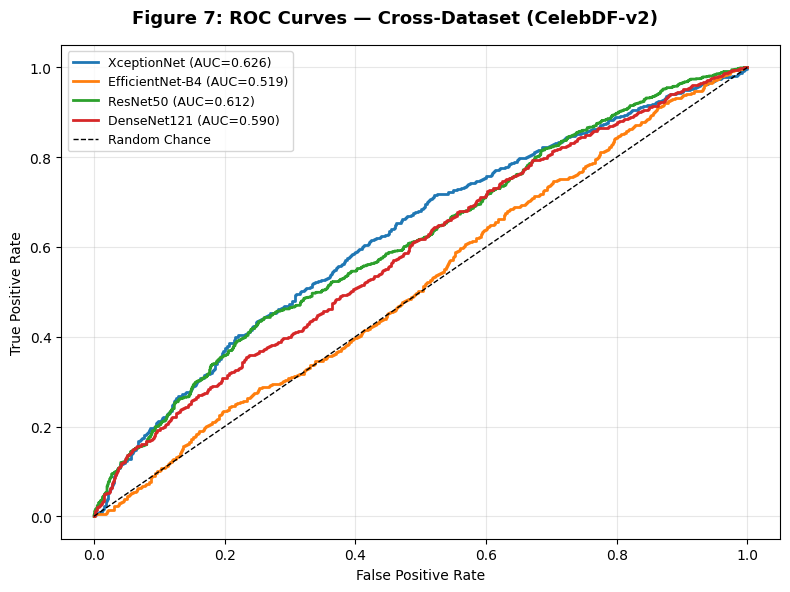

Figure 7 saved


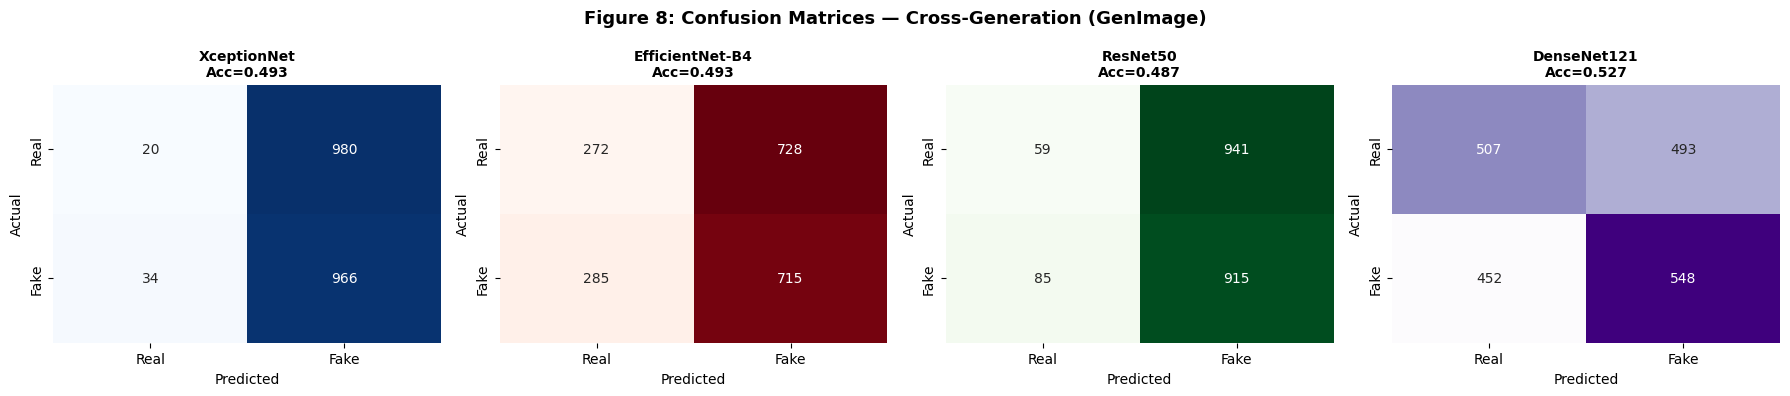

Figure 8 saved


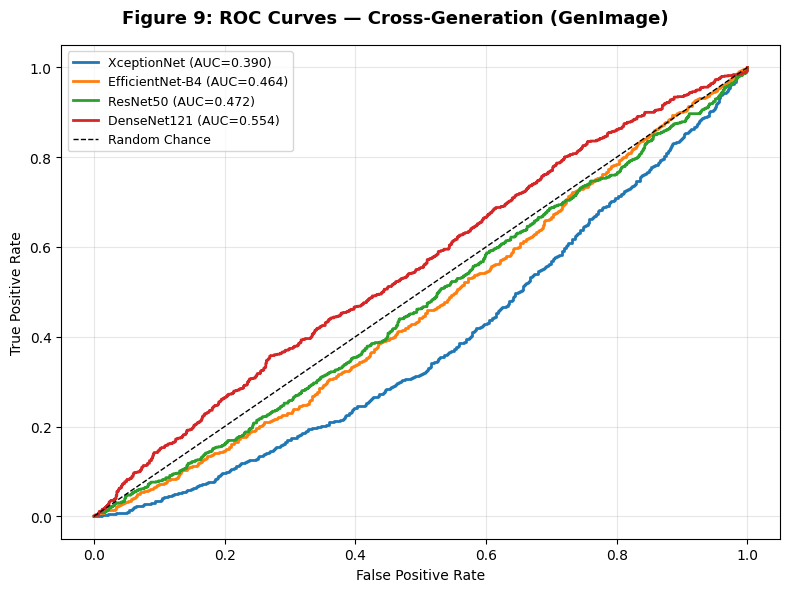

Figure 9 saved


In [ ]:
# -- Figures 4-9: Confusion Matrices + ROC Curves per condition ---------------
condition_map = [
    ('FF++',     'Within-Dataset (FF++)',       4, 5),
    ('CelebDF',  'Cross-Dataset (CelebDF-v2)',  6, 7),
    ('GenImage', 'Cross-Generation (GenImage)', 8, 9),
]
cmaps = ['Blues', 'Reds', 'Greens', 'Purples']

for ds, subtitle, cm_fignum, roc_fignum in condition_map:

    # Confusion Matrices
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'Figure {cm_fignum}: Confusion Matrices - {subtitle}',
                 fontsize=13, fontweight='bold')
    for i, name in enumerate(MODEL_NAMES):
        cm = results[name][ds]['cm']
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i],
                    xticklabels=['Real', 'Fake'],
                    yticklabels=['Real', 'Fake'],
                    ax=axes[i], cbar=False)
        acc = results[name][ds]['acc']
        axes[i].set_title(f'{name}\nAcc={acc:.3f}', fontweight='bold', fontsize=10)
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    plt.tight_layout()
    fname = f'/content/figures/figure{cm_fignum}_cm_{ds.lower().replace("-","").replace("+","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure {cm_fignum} saved')

    # ROC Curves
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.suptitle(f'Figure {roc_fignum}: ROC Curves - {subtitle}',
                 fontsize=13, fontweight='bold')
    for i, name in enumerate(MODEL_NAMES):
        r = results[name][ds]
        ax.plot(r['fpr'], r['tpr'], color=COLORS[i], lw=2,
                label=f'{name} (AUC={r["auc"]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f'/content/figures/figure{roc_fignum}_roc_{ds.lower().replace("-","").replace("+","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure {roc_fignum} saved')

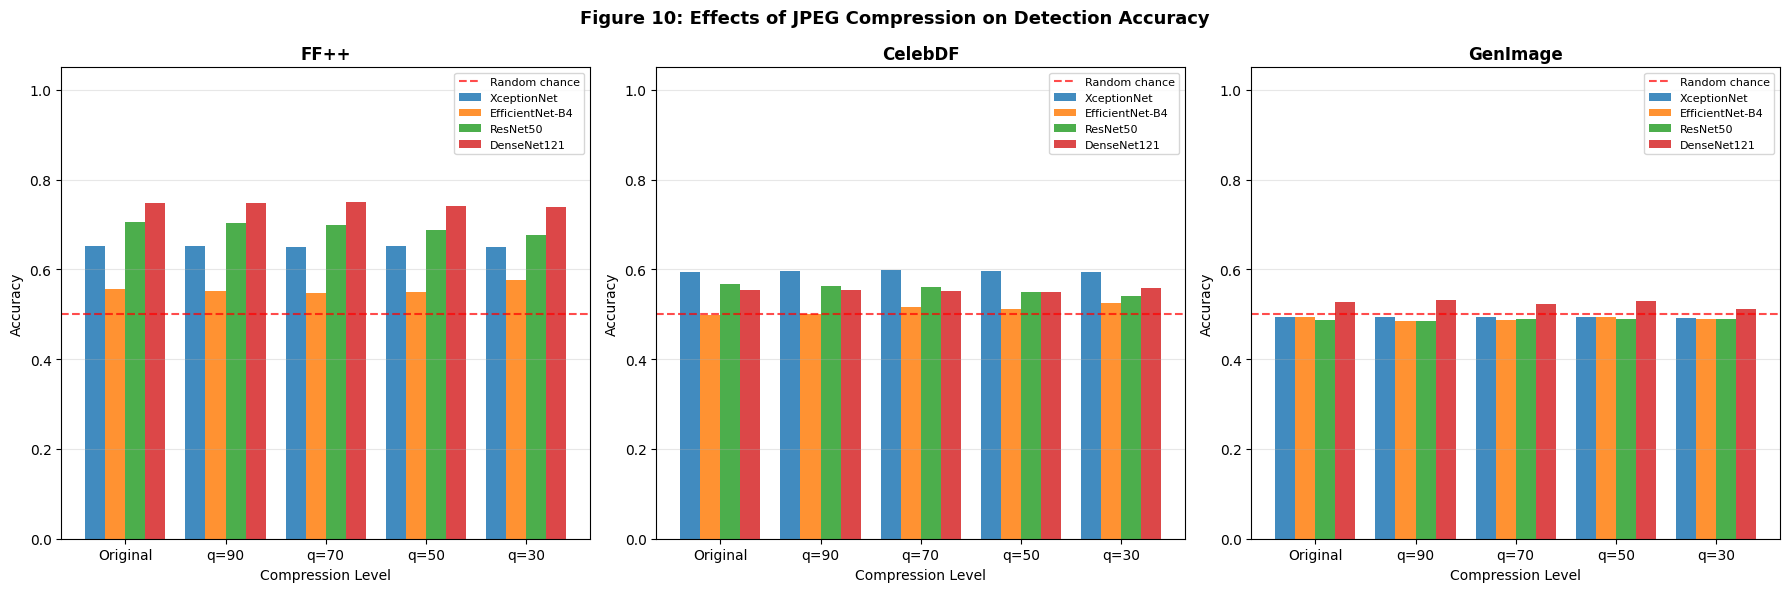

Figure 10 saved


In [ ]:
# -- Figure 10: JPEG Compression Bar Chart ------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 10: Effects of JPEG Compression on Detection Accuracy',
             fontsize=13, fontweight='bold')

x = np.arange(len(Q_LABELS))
width = 0.2

for j, ds in enumerate(DS_NAMES):
    for i, name in enumerate(MODEL_NAMES):
        orig = results[name][ds]['acc']
        vals = [orig] + [comp_results[name][ds][q]['acc'] for q in QUALITIES]
        axes[j].bar(x + i*width, vals, width, label=name, color=COLORS[i], alpha=0.85)
    axes[j].axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Random chance')
    axes[j].set_title(ds, fontweight='bold')
    axes[j].set_xlabel('Compression Level')
    axes[j].set_ylabel('Accuracy')
    axes[j].set_xticks(x + width*1.5)
    axes[j].set_xticklabels(Q_LABELS)
    axes[j].set_ylim(0, 1.05)
    axes[j].legend(fontsize=8)
    axes[j].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/figures/figure10_compression_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10 saved')

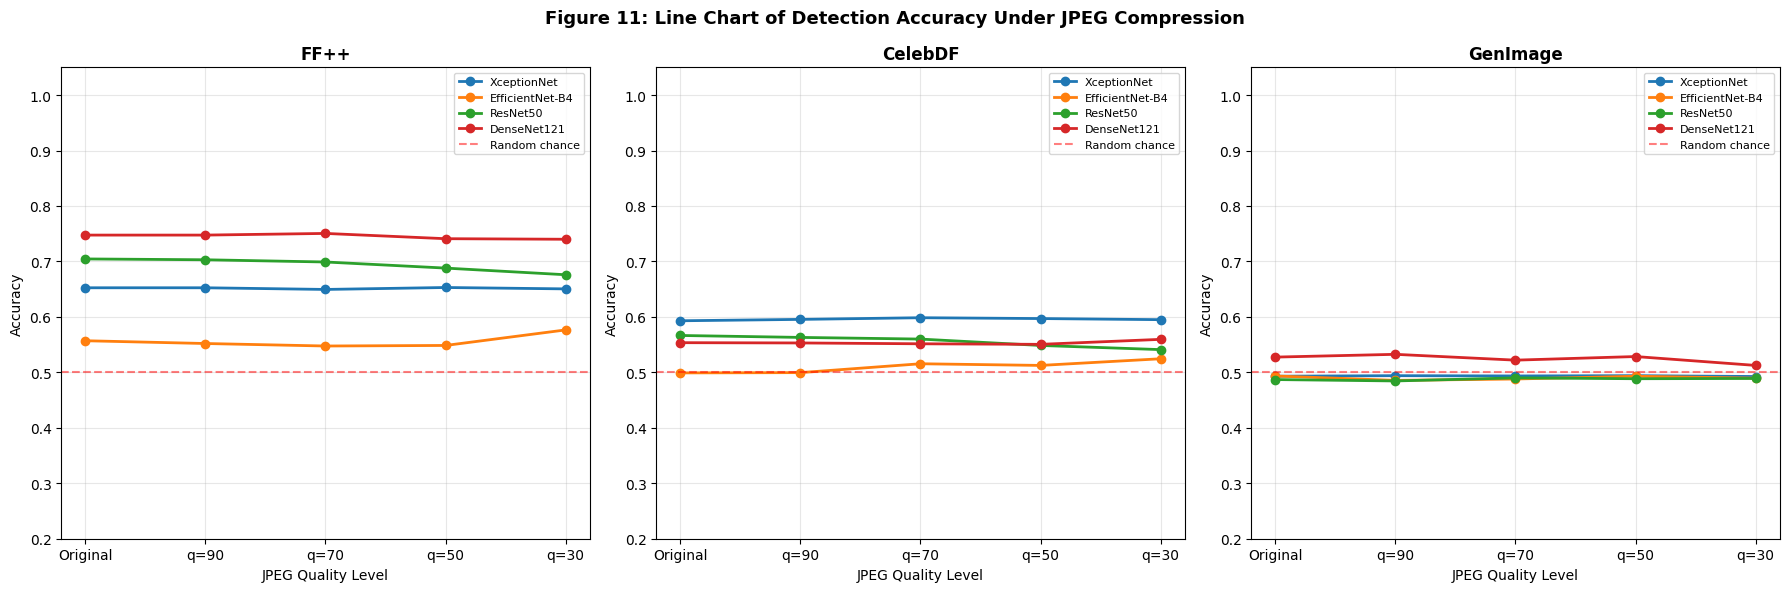

Figure 11 saved


In [ ]:
# -- Figure 11: JPEG Compression Line Chart -----------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 11: Line Chart of Detection Accuracy Under JPEG Compression',
             fontsize=13, fontweight='bold')

for j, ds in enumerate(DS_NAMES):
    for i, name in enumerate(MODEL_NAMES):
        orig = results[name][ds]['acc']
        vals = [orig] + [comp_results[name][ds][q]['acc'] for q in QUALITIES]
        axes[j].plot(Q_LABELS, vals, marker='o', lw=2, label=name, color=COLORS[i])
    axes[j].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random chance')
    axes[j].set_title(ds, fontweight='bold')
    axes[j].set_xlabel('JPEG Quality Level')
    axes[j].set_ylabel('Accuracy')
    axes[j].set_ylim(0.2, 1.05)
    axes[j].legend(fontsize=8)
    axes[j].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/figures/figure11_compression_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 11 saved')

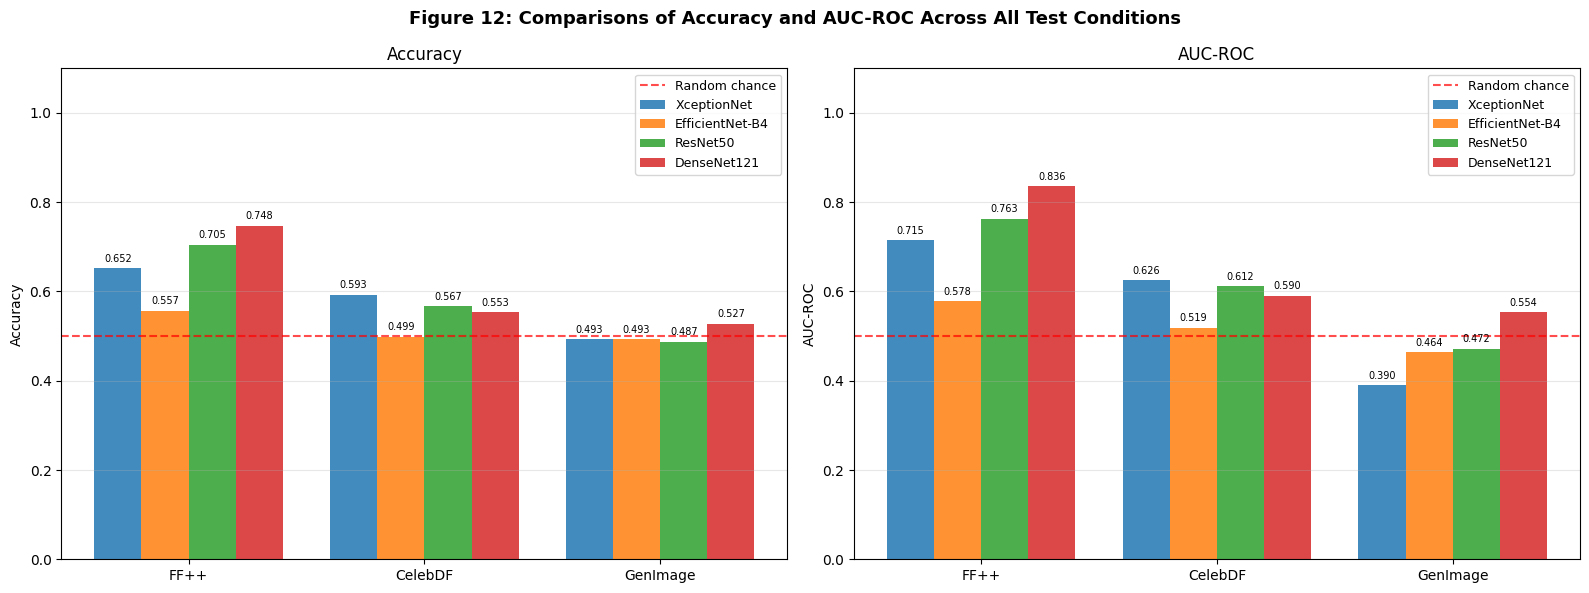

Figure 12 saved

All figures (3-12) complete!


In [ ]:
# -- Figure 12: Overall Accuracy + AUC-ROC Comparison ------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 12: Comparisons of Accuracy and AUC-ROC Across All Test Conditions',
             fontsize=13, fontweight='bold')

x = np.arange(len(DS_NAMES))
width = 0.2

for metric, ax, ylabel in [('acc', axes[0], 'Accuracy'), ('auc', axes[1], 'AUC-ROC')]:
    for i, name in enumerate(MODEL_NAMES):
        vals = [results[name][ds][metric] for ds in DS_NAMES]
        bars = ax.bar(x + i*width, vals, width, label=name, color=COLORS[i], alpha=0.85)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Random chance')
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(DS_NAMES)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_title('Accuracy')
axes[1].set_title('AUC-ROC')

plt.tight_layout()
plt.savefig('/content/figures/figure12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 12 saved')

print('\nAll figures (3-12) complete!')

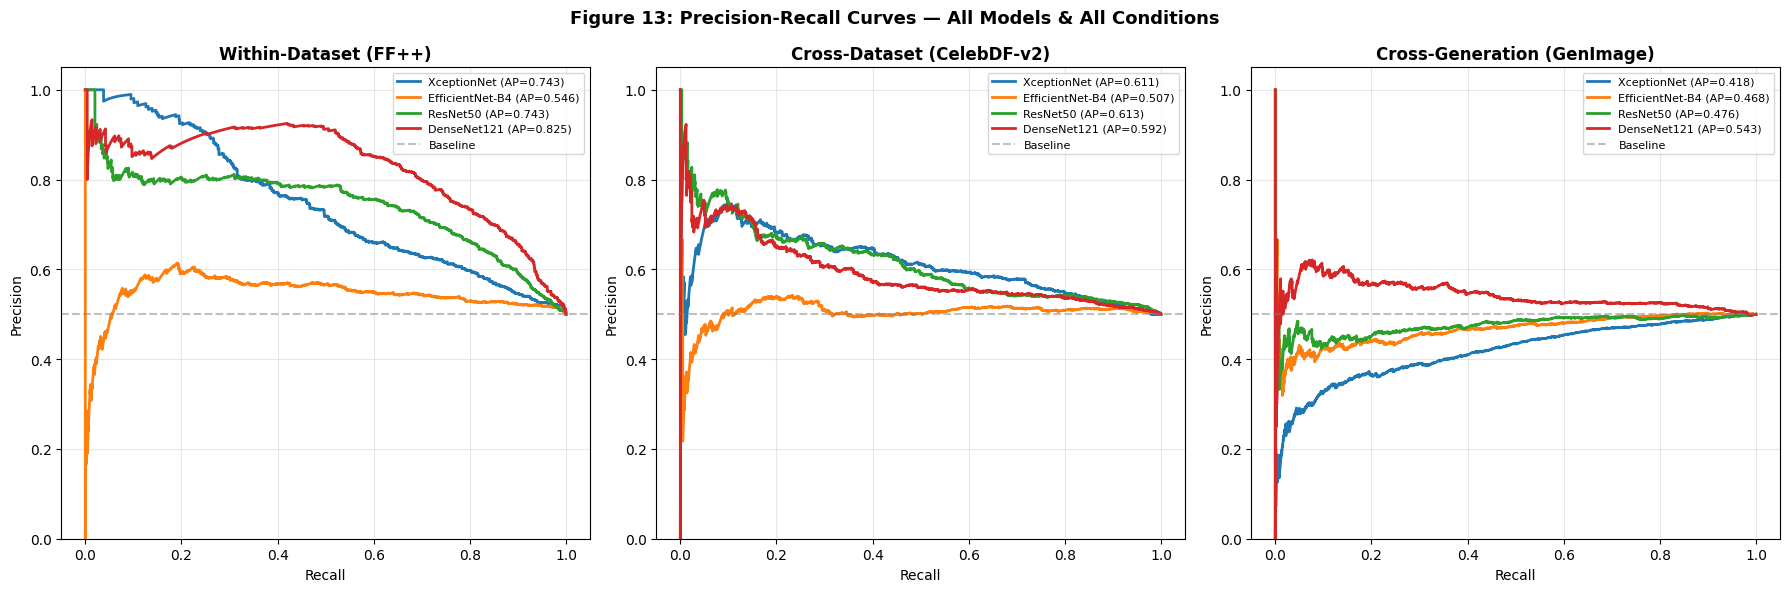

Figure 13 saved


In [ ]:
# -- Figure 13: Precision-Recall Curves - all models, all conditions ----------
# Uses probs/labels already stored by evaluate() in STEP 8 - no need to
# re-run inference here (previous version of this cell did, which was slow).
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 13: Precision-Recall Curves - All Models & All Conditions',
             fontsize=13, fontweight='bold')

condition_map_pr = [
    ('FF++',     'Within-Dataset (FF++)'),
    ('CelebDF',  'Cross-Dataset (CelebDF-v2)'),
    ('GenImage', 'Cross-Generation (GenImage)'),
]

for j, (ds, subtitle) in enumerate(condition_map_pr):
    for i, name in enumerate(MODEL_NAMES):
        r = results[name][ds]
        precision, recall, _ = precision_recall_curve(r['labels'], r['probs'])
        ap = average_precision_score(r['labels'], r['probs'])
        axes[j].plot(recall, precision, color=COLORS[i], lw=2,
                     label=f'{name} (AP={ap:.3f})')

    axes[j].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline')
    axes[j].set_title(subtitle, fontweight='bold')
    axes[j].set_xlabel('Recall')
    axes[j].set_ylabel('Precision')
    axes[j].set_ylim(0, 1.05)
    axes[j].legend(fontsize=8)
    axes[j].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/figures/figure13_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 13 saved')


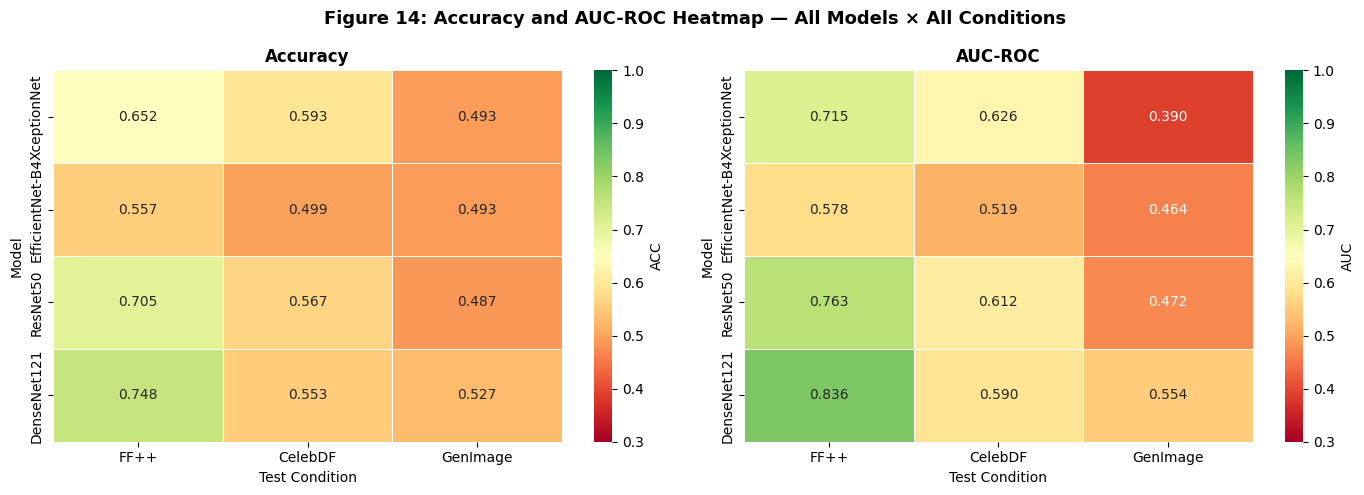

Figure 14 saved

All figures (3-14) complete!


In [ ]:
# -- Figure 14: Accuracy Heatmap - all models x all conditions ----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 14: Accuracy and AUC-ROC Heatmap - All Models x All Conditions',
             fontsize=13, fontweight='bold')

conditions = ['FF++', 'CelebDF', 'GenImage']

for ax, metric, title in [
    (axes[0], 'acc',  'Accuracy'),
    (axes[1], 'auc',  'AUC-ROC'),
]:
    matrix = np.array([
        [results[name][ds][metric] for ds in conditions]
        for name in MODEL_NAMES
    ])

    sns.heatmap(matrix,
                annot=True, fmt='.3f',
                cmap='RdYlGn',
                vmin=0.3, vmax=1.0,
                xticklabels=conditions,
                yticklabels=MODEL_NAMES,
                ax=ax,
                linewidths=0.5,
                cbar_kws={'label': metric.upper()})

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Test Condition')
    ax.set_ylabel('Model')

plt.tight_layout()
plt.savefig('/content/figures/figure14_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 14 saved')

print('\nAll figures (3-14) complete!')

---
## STEP 12 - Save Everything to Google Drive

In [ ]:
import shutil, os

RESULTS_DIR = '/content/drive/MyDrive/dataset/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# -- Model weights (/content/) -------------------------------------------------
model_files = [
    'xceptionnet_best.pth',
    'efficientnet_b4_best.pth',
    'resnet50_best.pth',
    'densenet121_best.pth',
]

# -- Plot files (/content/figures/) -------------------------------------------
plot_files = [
    'figure3_training_curves.png',
    'figure4_cm_ff.png',
    'figure5_roc_ff.png',
    'figure6_cm_celebdf.png',
    'figure7_roc_celebdf.png',
    'figure8_cm_genimage.png',
    'figure9_roc_genimage.png',
    'figure10_compression_bar.png',
    'figure11_compression_line.png',
    'figure12_model_comparison.png',
    'figure13_precision_recall.png',
    'figure14_heatmap.png',
]

for f in model_files:
    src = f'/content/{f}'
    dst = f'{RESULTS_DIR}/{f}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'[OK]   Saved: {f}')
    else:
        print(f'[MISS] Not found: {f}')

for f in plot_files:
    src = f'/content/figures/{f}'
    dst = f'{RESULTS_DIR}/{f}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'[OK]   Saved: {f}')
    else:
        print(f'[MISS] Not found: {f}')

print(f'\nAll files saved to {RESULTS_DIR}')

Saved: xceptionnet_best.pth
Saved: efficientnet_b4_best.pth
Saved: resnet50_best.pth
Saved: densenet121_best.pth
Saved: figure3_training_curves.png
Saved: figure4_cm_ff.png
Saved: figure5_roc_ff.png
Saved: figure6_cm_celebdf.png
Saved: figure7_roc_celebdf.png
Saved: figure8_cm_genimage.png
Saved: figure9_roc_genimage.png
Saved: figure10_compression_bar.png
Saved: figure11_compression_line.png
Saved: figure12_model_comparison.png
Saved: figure13_precision_recall.png
Saved: figure14_heatmap.png

All files saved to /content/drive/MyDrive/dataset/results
